# Differential abundance analysis of cardiac-tissue proteomics with pylimma

This tutorial demonstrates the AnnData-native pylimma workflow on a
bulk mass-spectrometry proteomics dataset. The matrix is already
log-transformed and median-normalised, so the analysis is a
classical microarray-style limma pipeline (no voom): build a design
matrix, fit per-protein linear models, moderate variances with
empirical Bayes, and read off the top differentially abundant
proteins.

## Dataset

**Mulvey et al. 2026, *Mol Cell Proteomics* 25(2):101510.**
[doi:10.1016/j.mcpro.2026.101510](https://doi.org/10.1016/j.mcpro.2026.101510).
Tissue proteomics from human left-ventricular tissue collected at
heart transplantation or LVAD implantation (heart-failure cases) or
from organ donors (controls). The original paper compares peripartum
cardiomyopathy hearts against non-peripartum cardiomyopathy and
controls; for this tutorial we collapse the two cardiomyopathy
groups into a single `heart_failure` arm and contrast it against
controls.

Cite the paper above (not pylimma) if you use this dataset in
published work.

**Shape**: 7,026 protein groups x 15 samples (6 control donors + 9
heart-failure cases).

## Pipeline

1. Load the protein abundance matrix and sample targets
2. Build an AnnData object (samples on `obs`, proteins on `var`)
3. Sample-correlation and PCA QC
4. Design matrix: `~ group`
5. `lm_fit` -> `e_bayes`
6. Top differentially abundant proteins (heart-failure vs control)
7. Volcano plot

## Loading the data

The two CSVs live under `_manuscript/data/` at the project root,
intentionally outside the pylimma package; they are not redistributed
with pylimma. They are produced by
`extract_mulvey_proteomics.py` from a private source CSV
that is not committed to the repository.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad

warnings.filterwarnings('ignore', category=FutureWarning)

# This notebook lives at pylimma/pylimma/examples/mulvey/
# - parents[1] = pylimma package root (source on PYTHONPATH)
# - parents[2] = project root, which contains _manuscript/data/
PKG_ROOT = Path.cwd().resolve().parents[1]
PROJECT_ROOT = Path.cwd().resolve().parents[2]
sys.path.insert(0, str(PKG_ROOT))

import pylimma

DATA_DIR = PROJECT_ROOT / '_manuscript' / 'data'
assert DATA_DIR.exists(), f'expected manuscript data at {DATA_DIR}'

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 12)

/Users/John/miniconda3/lib/python3.11/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


## 1. Load the matrix and targets

In [2]:
proteome = pd.read_csv(DATA_DIR / 'mulvey_proteome.csv.gz', index_col=0)
targets  = pd.read_csv(DATA_DIR / 'mulvey_targets.csv').set_index('sample_id')

protein_meta_cols = ['gene_symbol', 'num_psm',
                     'max_pep_prob', 'reference_intensity']
sample_cols       = [c for c in proteome.columns
                     if c not in protein_meta_cols]

X = proteome[sample_cols].T.values
var_df = proteome[protein_meta_cols].copy()
var_df.index.name = 'uniprot_id'

obs_df = targets.loc[sample_cols].copy()
obs_df['group'] = pd.Categorical(obs_df['group'],
                                  categories=['control', 'heart_failure'],
                                  ordered=False)

adata = ad.AnnData(X=X, obs=obs_df, var=var_df)
adata.obs_names = sample_cols
adata.var_names = var_df.index

print(f'AnnData shape: {adata.shape}  (samples x proteins)')
print(f'\ngroup counts:\n{adata.obs.group.value_counts()}')
adata.var.head()

AnnData shape: (15, 7026)  (samples x proteins)

group counts:
group
heart_failure    9
control          6
Name: count, dtype: int64


,gene_symbol,num_psm,max_pep_prob,reference_intensity
uniprot_id,,,,
A0A075B6H7,IGKV3-7,2,1.0000,16.264649
A0A075B6H9,IGLV4-69,2,1.0000,18.129858
A0A075B6I0,IGLV8-61,2,1.0000,18.895982
A0A075B6I1,IGLV4-60,3,1.0000,17.037598
A0A075B6I4,IGLV10-54,2,0.9998,15.915174


## 2. Sample-correlation and PCA QC

Two diagnostics that should be inspected before any DE analysis on
proteomics data: a sample-correlation heatmap (highly correlated
samples cluster within group) and a PCA projection (separation
between groups along an early PC indicates the contrast carries the
expected signal).

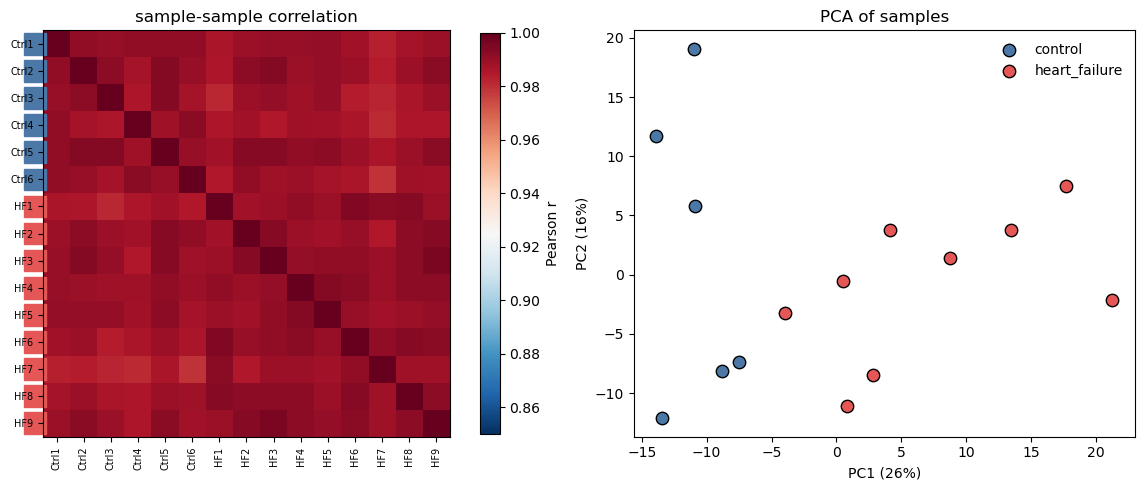

In [3]:
fig, (axCor, axPca) = plt.subplots(1, 2, figsize=(12, 5))

# Sample-sample Pearson correlation across proteins.
corr = pd.DataFrame(
    np.corrcoef(adata.X),
    index=adata.obs_names, columns=adata.obs_names,
)
group_palette = {'control': '#4c78a8', 'heart_failure': '#e45756'}
row_colors = adata.obs['group'].map(group_palette)

im = axCor.imshow(corr.values, cmap='RdBu_r', vmin=0.85, vmax=1.0)
axCor.set_xticks(range(len(corr))); axCor.set_yticks(range(len(corr)))
axCor.set_xticklabels(corr.columns, rotation=90, fontsize=7)
axCor.set_yticklabels(corr.index,  fontsize=7)
for k, c in enumerate(row_colors):
    axCor.add_patch(plt.Rectangle((-1.2, k - 0.4), 0.8, 0.8,
                                   color=c, clip_on=False))
axCor.set_title('sample-sample correlation')
plt.colorbar(im, ax=axCor, fraction=0.04, pad=0.06, label='Pearson r')

# PCA on samples (centre proteins, drop any all-NaN rows just in case).
Xc = adata.X - adata.X.mean(axis=0, keepdims=True)
U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
pcs = U * s
var_explained = (s ** 2) / (s ** 2).sum()

for grp, colour in group_palette.items():
    m = (adata.obs['group'] == grp).values
    axPca.scatter(pcs[m, 0], pcs[m, 1], s=80,
                   color=colour, edgecolor='black', label=grp)
axPca.set_xlabel(f'PC1 ({var_explained[0]:.0%})')
axPca.set_ylabel(f'PC2 ({var_explained[1]:.0%})')
axPca.set_title('PCA of samples')
axPca.legend(frameon=False)

fig.tight_layout()
plt.show()

## 3. Design matrix and contrast

Two-level group factor with `control` as the reference level. The
design has an intercept plus a `heart_failure` indicator; the
contrast that asks "what is differentially abundant in heart failure
versus control" is just the coefficient on the indicator (a
one-element contrast vector `[0, 1]`).

In [4]:
group  = adata.obs['group']
design = pd.DataFrame({
    'Intercept':     1.0,
    'heart_failure': (group == 'heart_failure').astype(float).values,
}, index=adata.obs_names)

contrasts = pylimma.make_contrasts(HFvsCtrl='heart_failure', levels=design)

print('design matrix:')
print(design.head(3))
print('\ncontrast:')
print(contrasts)

design matrix:
       Intercept  heart_failure
Ctrl1        1.0            0.0
Ctrl2        1.0            0.0
Ctrl3        1.0            0.0

contrast:
               HFvsCtrl
Intercept           0.0
heart_failure       1.0


## 4. lm_fit -> contrasts_fit -> e_bayes

Pure AnnData pipeline. The fit is stored in `adata.uns['pylimma']`
and survives `write_h5ad` if you want to round-trip it through
disk. No `voom` step here: the input is already log-scale normalised
abundance, so we feed it straight into `lm_fit`.

In [5]:
pylimma.lm_fit(adata, design)
pylimma.contrasts_fit(adata, contrasts=contrasts)
pylimma.e_bayes(adata)

print('keys stored in adata.uns["pylimma"]:')
print(sorted(adata.uns['pylimma'].keys()))

keys stored in adata.uns["pylimma"]:
['Amean', 'F', 'F_p_value', 'coef_names', 'coefficients', 'contrast_names', 'contrasts', 'cov_coefficients', 'design', 'df_prior', 'df_residual', 'df_total', 'genes', 'lods', 'method', 'p_value', 'pivot', 'proportion', 'rank', 's2_post', 's2_prior', 'sigma', 'stdev_unscaled', 't', 'targets', 'var_prior']


## 5. Top differentially abundant proteins

In [6]:
top = pylimma.top_table(adata, coef='HFvsCtrl',
                         number=np.inf, sort_by='p')

# Carry over gene symbols from adata.var so the table is readable.
top = top.join(adata.var[['gene_symbol']], how='left')

n_sig_05 = int((top['adj_p_value'] < 0.05).sum())
n_sig_01 = int((top['adj_p_value'] < 0.01).sum())
print(f'differentially abundant proteins at adj_p_value < 0.05: {n_sig_05:,}')
print(f'differentially abundant proteins at adj_p_value < 0.01: {n_sig_01:,}')

display_cols = ['gene_symbol', 'log_fc', 'ave_expr', 't',
                'p_value', 'adj_p_value', 'b']
top.loc[:, display_cols].head(15).round(3)

differentially abundant proteins at adj_p_value < 0.05: 267
differentially abundant proteins at adj_p_value < 0.01: 0


,gene_symbol,log_fc,ave_expr,t,p_value,adj_p_value,b
gene,,,,,,,
P02768,ALB,0.776,10.394,7.232,0.0,0.012,5.006
O43272,PRODH,-1.117,0.421,-6.932,0.0,0.012,4.550
Q9HDC5,JPH1,-0.522,-0.142,-6.422,0.0,0.015,3.738
Q9UBX5,FBLN5,1.266,2.883,6.364,0.0,0.015,3.644
P0DJI8,SAA1,-1.665,0.410,-6.290,0.0,0.015,3.522
Q8WTS1,ABHD5,-0.533,-0.134,-6.077,0.0,0.015,3.166
Q53HC5,KLHL26,0.466,-3.695,6.060,0.0,0.015,3.137
P31939,ATIC,-0.412,4.120,-6.045,0.0,0.015,3.112
Q6UX53,METTL7B,-0.867,0.794,-5.841,0.0,0.015,2.762


## 6. Volcano plot

Standard summary plot. Each point is one protein group; the x-axis
is the log fold-change in heart failure relative to control, the
y-axis is `-log10(p_value)`. Proteins past `adj_p_value < 0.05` are
coloured red (up in heart failure) or blue (down in heart failure).
Top hits by signed log fold-change are labelled with their gene
symbol.

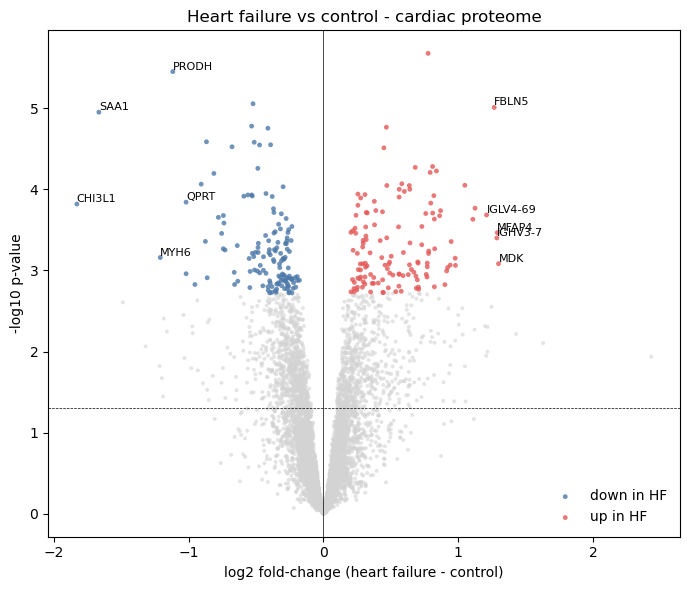

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))

sig_up   = (top['adj_p_value'] < 0.05) & (top['log_fc'] > 0)
sig_down = (top['adj_p_value'] < 0.05) & (top['log_fc'] < 0)
ns       = ~(sig_up | sig_down)

nlp = -np.log10(np.maximum(top['p_value'].values, 1e-300))

ax.scatter(top.loc[ns, 'log_fc'],   nlp[ns.values],
           s=8, color='lightgrey', alpha=0.6, edgecolor='none')
ax.scatter(top.loc[sig_down, 'log_fc'], nlp[sig_down.values],
           s=12, color='#4c78a8', alpha=0.8,
           edgecolor='none', label='down in HF')
ax.scatter(top.loc[sig_up, 'log_fc'],   nlp[sig_up.values],
           s=12, color='#e45756', alpha=0.8,
           edgecolor='none', label='up in HF')

# Label the top 5 up and top 5 down by signed log fold change among the
# significant proteins (those past adj_p_value < 0.05). Gene symbols
# only - some entries have multi-gene proteingroup labels which we skip
# to keep the plot legible.
sig = top[top['adj_p_value'] < 0.05].copy()
top_up   = sig.sort_values('log_fc', ascending=False).head(5)
top_down = sig.sort_values('log_fc', ascending=True ).head(5)
for _, row in pd.concat([top_up, top_down]).iterrows():
    label = row['gene_symbol']
    if not isinstance(label, str) or ';' in label or label == '':
        continue
    ax.annotate(label, (row['log_fc'], -np.log10(max(row['p_value'], 1e-300))),
                fontsize=8, ha='left', va='bottom')

ax.axhline(-np.log10(0.05), color='black', lw=0.5, linestyle='--')
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('log2 fold-change (heart failure - control)')
ax.set_ylabel('-log10 p-value')
ax.set_title('Heart failure vs control - cardiac proteome')
ax.legend(frameon=False, loc='lower right')
fig.tight_layout()
plt.show()

## 7. Summary

This tutorial showed the bulk-MS proteomics workflow with pylimma
end-to-end on AnnData. The same pattern - load the abundance matrix
and sample annotations, build the AnnData, define a design matrix,
call `lm_fit` -> `contrasts_fit` -> `e_bayes` -> `top_table` - works
unchanged on any pre-normalised log-abundance matrix from a
proteomics or microarray experiment.

Note that no `voom` step appears: voom is for raw integer counts
where the mean-variance relationship needs to be modelled. For
log-scale abundance from MS proteomics or microarrays, the classical
limma pipeline applies directly.

## References

- Mulvey, J. F. *et al.* (2026). An Unbiased Molecular Characterization
  of Peripartum Cardiomyopathy Hearts Identifies Mast Cell Chymase
  as a New Diagnostic Candidate. *Mol Cell Proteomics* 25(2), 101510.
  [doi:10.1016/j.mcpro.2026.101510](https://doi.org/10.1016/j.mcpro.2026.101510).
- Smyth, G. K. (2004). Linear models and empirical Bayes methods
  for assessing differential expression in microarray experiments.
  *Stat Appl Genet Mol Biol* 3, Article 3.
- Ritchie, M. E. *et al.* (2015). limma powers differential
  expression analyses for RNA-sequencing and microarray studies.
  *Nucleic Acids Res* 43(7), e47.